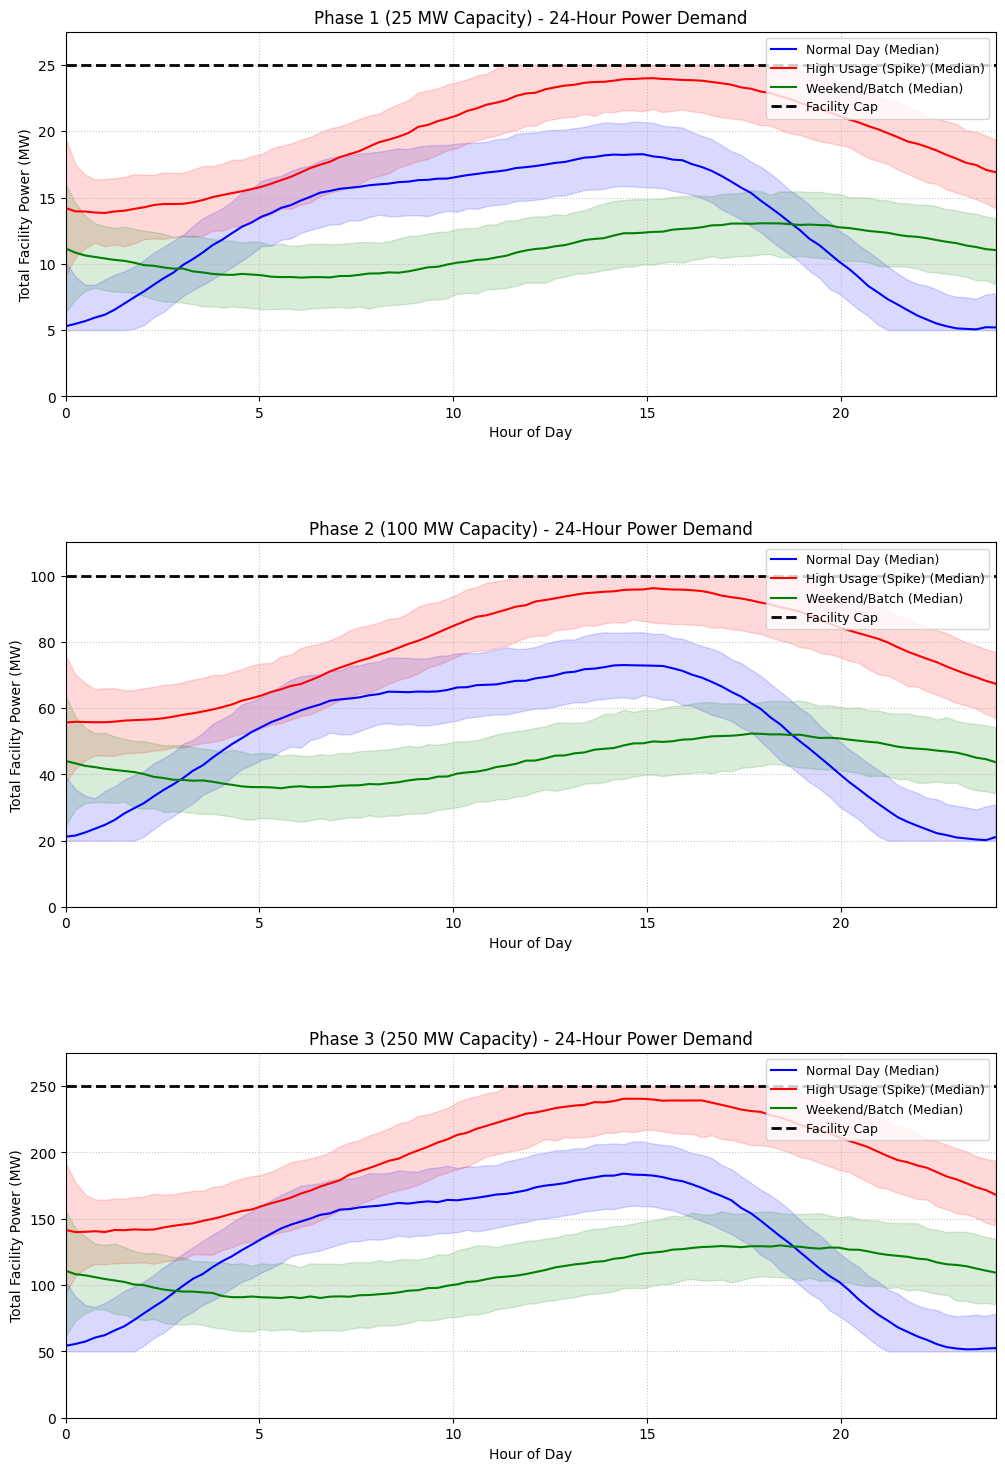

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Facility Constants
PUE = 1.2
IDLE_FRACTION = 0.20 # Servers draw 20% max power even when idle
PHASES = {'Phase 1': 25, 'Phase 2': 100, 'Phase 3': 250} # MW
SCENARIOS = ['Normal Day', 'High Usage (Spike)', 'Weekend/Batch']
TIME_STEPS = 96 # 15-minute intervals over 24 hours
SIM_ITERATIONS = 1000

# Time array (0 to 24 hours)
time_hours = np.linspace(0, 24, TIME_STEPS)

def generate_base_utilization(scenario):
    """Generate the mean utilization curve U(t) for a given scenario using superposition of sine waves."""
    if scenario == 'Normal Day':
        # Bimodal distribution: Peaks around 10 AM and 8 PM
        u = 0.4 + 0.3 * np.sin(np.pi * (time_hours - 6) / 12) + 0.1 * np.sin(np.pi * (time_hours - 14) / 6)
    elif scenario == 'High Usage (Spike)':
        # Unimodal skewed: Sustained heavy daytime load
        u = 0.7 + 0.25 * np.sin(np.pi * (time_hours - 8) / 14)
    else: # Weekend/Batch
        # Low amplitude, flat curve for background tasks
        u = 0.3 + 0.1 * np.sin(np.pi * (time_hours - 12) / 12)

    return np.clip(u, 0, 1)

def run_monte_carlo(max_power_mw, scenario, iterations=SIM_ITERATIONS):
    # Calculate IT bounds based on PUE and Idle constraints
    max_it_power = max_power_mw / PUE
    base_it_power = max_it_power * IDLE_FRACTION

    mean_u = generate_base_utilization(scenario)

    # Standard deviation for the stochastic noise
    volatility = 0.15

    simulations = np.zeros((iterations, TIME_STEPS))

    for i in range(iterations):
        # 1. Generate Gaussian noise
        noise = np.random.normal(0, volatility, TIME_STEPS)
        # 2. Smooth noise (4 periods = 1 hour) to mimic realistic server ramp rates
        smoothed_noise = pd.Series(noise).rolling(window=4, min_periods=1).mean().values

        # 3. Apply noise to base utilization and constrain between 0% and 100%
        u_sim = mean_u + smoothed_noise
        u_sim = np.clip(u_sim, 0.0, 1.0)

        # 4. Map utilization to physical power constraints
        it_power = base_it_power + (max_it_power - base_it_power) * u_sim
        total_power = it_power * PUE

        # 5. Hard clip at facility transformer limit
        total_power = np.clip(total_power, 0, max_power_mw)
        simulations[i, :] = total_power

    # Extract the 5th, 50th (Median), and 95th percentiles across all 1000 iterations
    p5 = np.percentile(simulations, 5, axis=0)
    p50 = np.percentile(simulations, 50, axis=0)
    p95 = np.percentile(simulations, 95, axis=0)

    return p5, p50, p95

# Plotting Execution
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

for idx, (phase_name, max_p) in enumerate(PHASES.items()):
    ax = axes[idx]
    colors = {'Normal Day': 'blue', 'High Usage (Spike)': 'red', 'Weekend/Batch': 'green'}

    for scenario in SCENARIOS:
        p5, p50, p95 = run_monte_carlo(max_p, scenario)

        # Plot Median (Solid Line)
        ax.plot(time_hours, p50, label=f'{scenario} (Median)', color=colors[scenario])
        # Plot 90% Confidence Interval (Shaded Region)
        ax.fill_between(time_hours, p5, p95, color=colors[scenario], alpha=0.15)

    ax.set_title(f'{phase_name} ({max_p} MW Capacity) - 24-Hour Power Demand')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Total Facility Power (MW)')
    ax.set_xlim(0, 24)
    ax.set_ylim(0, max_p * 1.1)
    ax.axhline(max_p, color='black', linestyle='--', linewidth=2, label='Facility Cap')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.7)

plt.show()